In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = sns.load_dataset('penguins')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


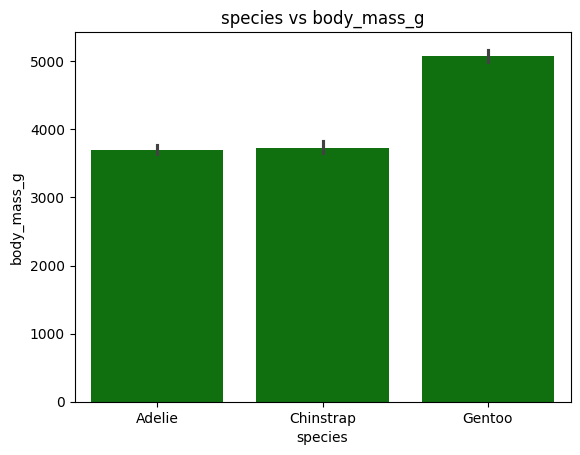

In [57]:
#task 1
#plt.bar(df['species'],df['body_mass_g'])
#plt.xlabel('species')
#plt.ylabel('body_mass_g')
#plt.title('species vs body_mass_g')
#plt.show()
sns.barplot(x='species', y='body_mass_g' , data=df , color="green")
plt.title('species vs body_mass_g')
plt.show()

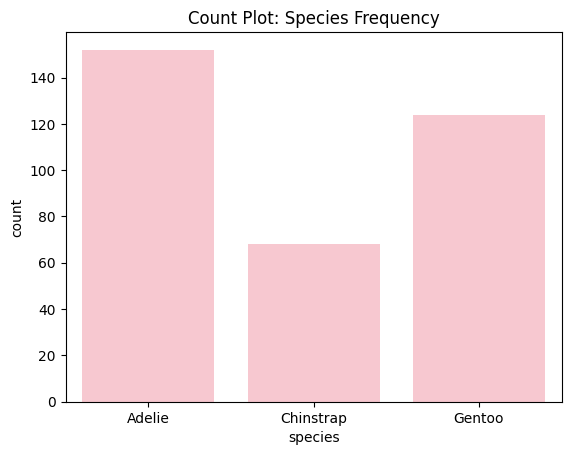

In [55]:
#task 2
sns.countplot(data = df , x='species', color="pink")
plt.title('Count Plot: Species Frequency')
plt.show()

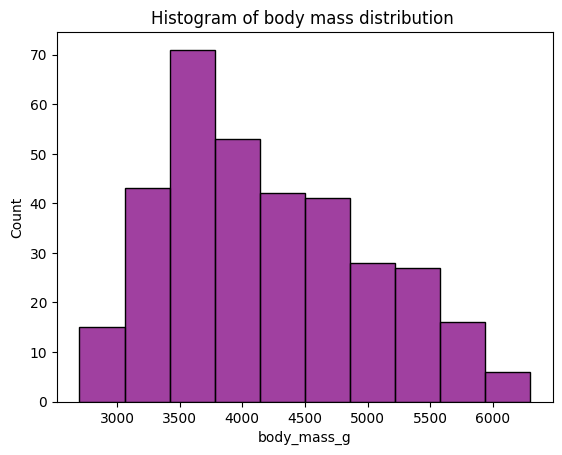

In [53]:
#task 3
sns.histplot(data=df , x ='body_mass_g', bins=10 ,color="purple")
plt.title('Histogram of body mass distribution ')
plt.show()
#it is not symmetric its right skewed

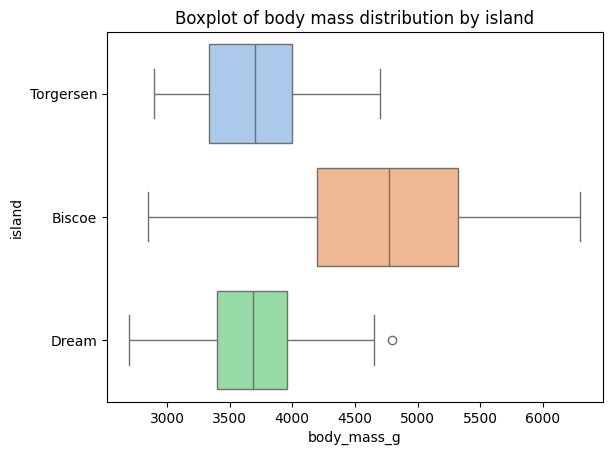

In [52]:
#task 4
sns.boxplot(data= df , x='body_mass_g' , y='island' ,hue='island', palette="pastel")
plt.title('Boxplot of body mass distribution by island')
plt.show()

# dream island has 1 outlier outside the whiskers

In [34]:
#task 5
q1 = df['body_mass_g'].quantile(0.25)
q3 = df['body_mass_g'].quantile(0.75)
IQR = q3 - q1
lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR
outliers = df[(df['body_mass_g'] < lower) | (df['body_mass_g'] > upper)]
print("outliers : " ,len(outliers))

outliers :  0


this  has 0 while the last task has 1 its because this is entirely on it own the numeric col and in that task we were splitting it by a category island specifically

In [35]:
#task 6
from scipy import stats
df['zscore'] = stats.zscore(df['body_mass_g'])
outliers_z = df[df['zscore'].abs()>3]
print("outliers : " , len(outliers_z))

outliers :  0


iqr are the same as the zscore both give outliers as 0 while the boxplot showed 1

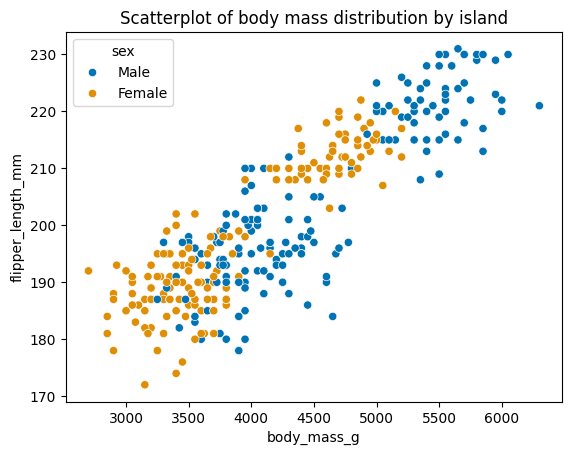

In [58]:
#task 7
sns.scatterplot(data = df , x = 'body_mass_g' , y = 'flipper_length_mm' , hue = 'sex' , palette="colorblind")
plt.title('Scatterplot of body mass distribution by island')
plt.show()

as body mass increases so does flipper length ther is a positive correlation
and the categorical colored grap shows that female are more likely to have small body mass and then small flipper length becuase of it compared to male penguins


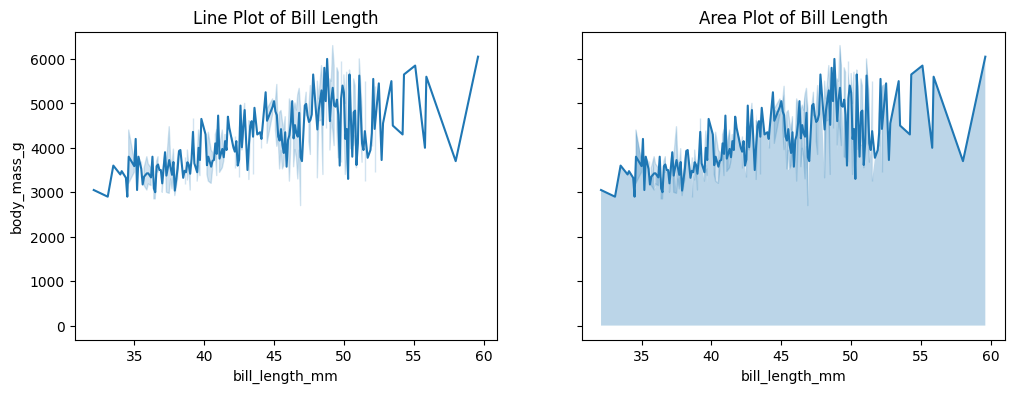

In [68]:
#task 8
df_sorted = df.sort_values(by='bill_length_mm')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

plt.sca(ax1)
plt.title("Line Plot of Bill Length")
sns.lineplot(data=df_sorted, x="bill_length_mm", y="body_mass_g")
plt.sca(ax2)
plt.title("Area Plot of Bill Length")
sns.lineplot(data=df_sorted, x="bill_length_mm", y="body_mass_g")
plt.fill_between(df_sorted["bill_length_mm"], df_sorted["body_mass_g"], alpha=0.3)

plt.show()


 Adding the area fill transforms this line into a solid grounding the chart and making the penguin weights feel much more massive while line plot  emphasizing the exact path of change

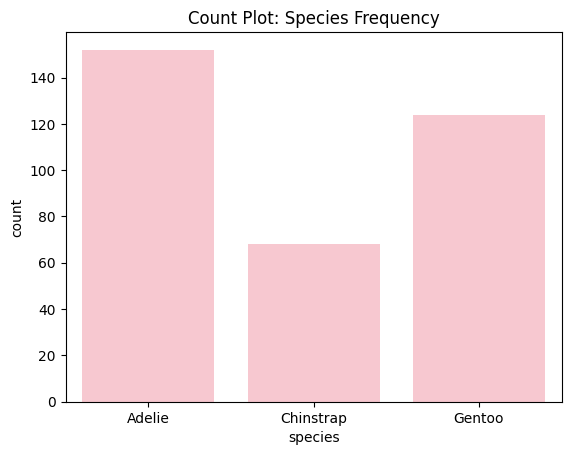

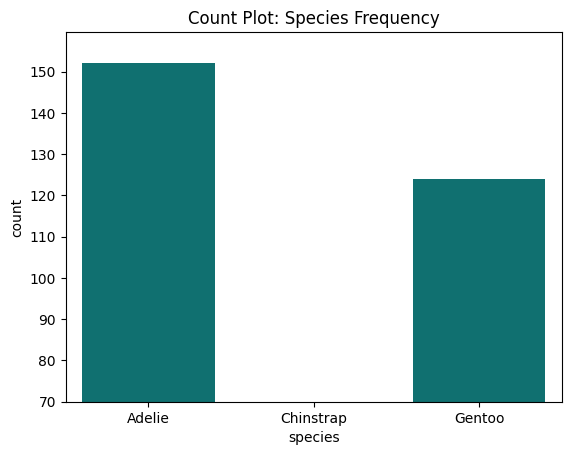

In [69]:
#task 9
#task 2
sns.countplot(data = df , x='species', color="pink")
plt.title('Count Plot: Species Frequency')
plt.show()

sns.countplot(data = df , x='species', color="teal")
plt.title('Count Plot: Species Frequency')
plt.ylim(bottom=70)
plt.show()

the data didnt change but the limit of y axis changed to min = 70 so truncating it makes the chinstrap species look non existent even though it does exist npot missing it shows how data integeraty depends on the author and this way data representation is good without truncating the y axis